In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = r"C:\Users\R\Downloads\archive(1)\sales_data_sample.csv"
data = pd.read_csv(url,encoding='latin1')

In [2]:
data.drop(['POSTALCODE','PHONE','ADDRESSLINE1','ADDRESSLINE2','CUSTOMERNAME','CONTACTLASTNAME','CONTACTFIRSTNAME'],axis=1,inplace=True)

In [3]:
data.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CITY,STATE,COUNTRY,TERRITORY,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,NYC,NY,USA,NaN,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims,NaN,France,EMEA,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Paris,NaN,France,EMEA,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Pasadena,CA,USA,NaN,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,San Francisco,CA,USA,NaN,Medium


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ORDERNUMBER      2823 non-null   int64  
 1   QUANTITYORDERED  2823 non-null   int64  
 2   PRICEEACH        2823 non-null   float64
 3   ORDERLINENUMBER  2823 non-null   int64  
 4   SALES            2823 non-null   float64
 5   ORDERDATE        2823 non-null   object 
 6   STATUS           2823 non-null   object 
 7   QTR_ID           2823 non-null   int64  
 8   MONTH_ID         2823 non-null   int64  
 9   YEAR_ID          2823 non-null   int64  
 10  PRODUCTLINE      2823 non-null   object 
 11  MSRP             2823 non-null   int64  
 12  PRODUCTCODE      2823 non-null   object 
 13  CITY             2823 non-null   object 
 14  STATE            1337 non-null   object 
 15  COUNTRY          2823 non-null   object 
 16  TERRITORY        1749 non-null   object 
 17  DEALSIZE      

In [5]:
if 'level_0' in data.columns:
    data = data.drop(columns=['level_0'])

data.dropna(inplace=True)
data.reset_index(drop=True,inplace=True)

In [6]:
data.head(1)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CITY,STATE,COUNTRY,TERRITORY,DEALSIZE
0,10223,37,100.0,1,3965.66,2/20/2004 0:00,Shipped,1,2,2004,Motorcycles,95,S10_1678,Melbourne,Victoria,Australia,APAC,Medium


In [7]:
data.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,263.000000,263.000000,263.00000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000
mean,10271.494297,34.155894,83.16038,6.653992,3410.767110,2.665399,6.923954,2003.908745,98.973384
std,94.371398,9.958810,19.78292,4.263064,1756.119591,1.260914,4.006902,0.698444,39.420265
min,10120.000000,15.000000,26.88000,1.000000,553.950000,1.000000,1.000000,2003.000000,33.000000
25%,10193.000000,26.000000,66.39000,3.000000,2201.430000,1.000000,3.000000,2003.000000,68.000000
50%,10270.000000,34.000000,94.62000,6.000000,2953.860000,3.000000,7.000000,2004.000000,95.000000
75%,10361.000000,42.000000,100.00000,10.000000,4315.340000,4.000000,11.000000,2004.000000,118.000000
max,10420.000000,66.000000,100.00000,18.000000,10758.000000,4.000000,12.000000,2005.000000,214.000000


In [8]:
total_sales = data["SALES"].sum()
print(f"total sales = {total_sales}")

total sales = 897031.75


In [9]:
top_products = data["PRODUCTLINE"].value_counts().head()
print(top_products)

PRODUCTLINE
Vintage Cars        74
Classic Cars        62
Planes              50
Motorcycles         35
Trucks and Buses    23
Name: count, dtype: int64


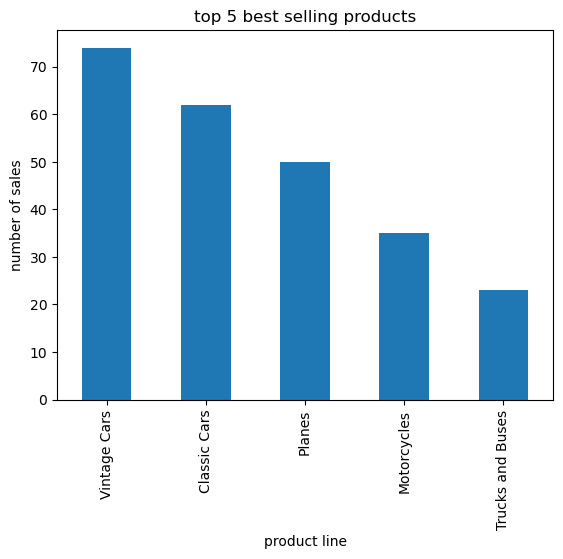

In [12]:
top_products.plot(kind='bar')
plt.title('top 5 best selling products')
plt.xlabel('product line')
plt.ylabel('number of sales')
plt.show()

In [14]:
data['ORDERDATE'] = pd.to_datetime(data['ORDERDATE'])
data.set_index('ORDERDATE',inplace=True)

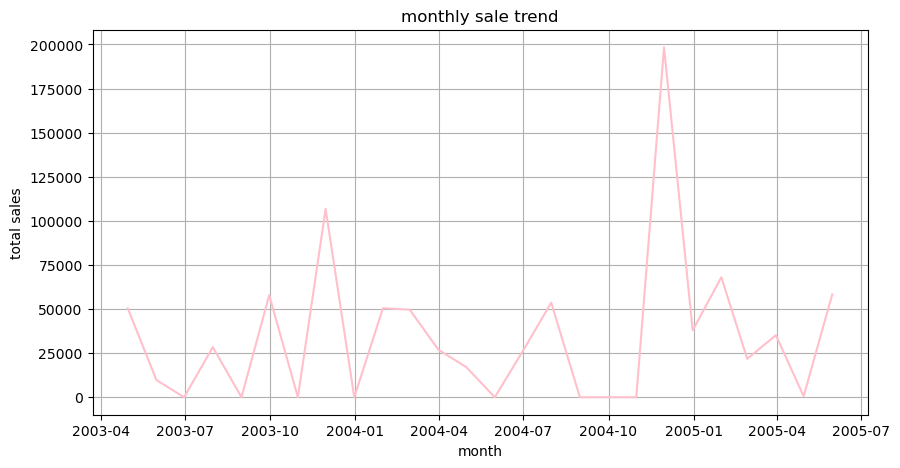

In [17]:
monthly_sales = data.resample('M')['SALES'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales,color='pink')
plt.title('monthly sale trend')
plt.xlabel('month')
plt.ylabel('total sales')
plt.grid()
plt.show()

In [18]:
print(monthly_sales.sort_values(ascending=False).head(5))

ORDERDATE
2004-11-30    198444.81
2003-11-30    106769.30
2005-01-31     68043.56
2005-05-31     58349.52
2003-09-30     57832.05
Name: SALES, dtype: float64


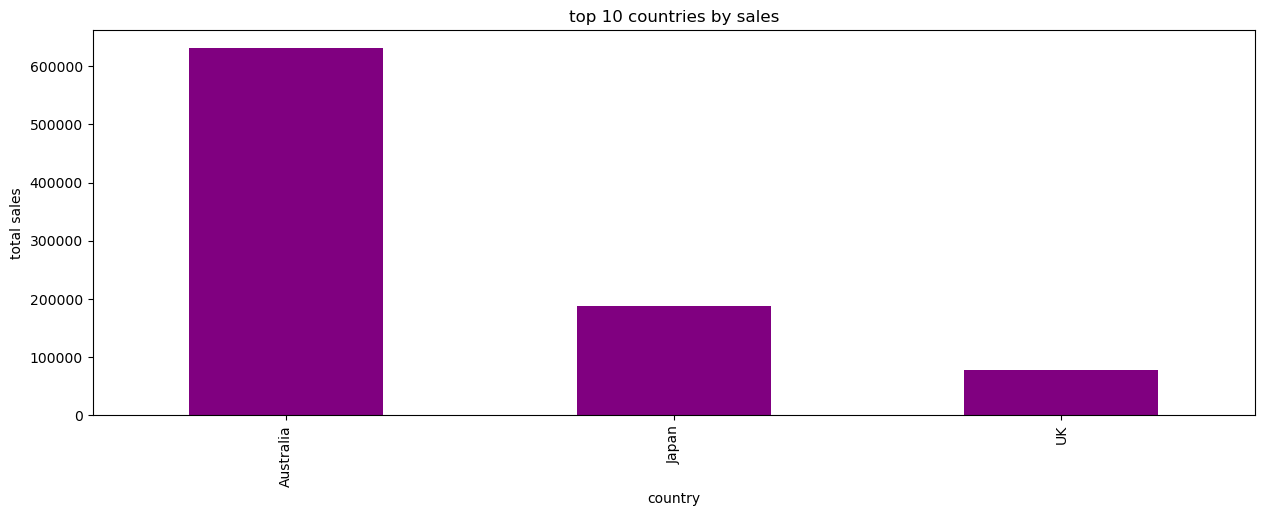

In [27]:
country_sales = data.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False)
plt.figure(figsize=(15,5))
country_sales.plot(kind='bar',color='purple')
plt.title('top 10 countries by sales')
plt.xlabel('country')
plt.ylabel('total sales')
plt.show()